# Análise de Qualidade dos Dados Brutos - Amazon Products
## Identificação de Dados Problemáticos e Necessidade de Limpeza

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [ ]:
df = pd.read_csv('data/amazon_products_sales_data_uncleaned.csv')
print(f"📊 Total de registros: {len(df):,}")
print(f"📋 Total de colunas: {len(df.columns)}")
display(df)

📊 Total de registros: 42,675
📋 Total de colunas: 16


## 1. Análise de Dados Faltantes

In [22]:
# Calcular dados faltantes por coluna
missing_data = pd.DataFrame({
    'Coluna': df.columns,
    'Valores Nulos': df.isnull().sum().values,
    'Valores Vazios': (df == '').sum().values,
    'Total Problemático': df.isnull().sum().values + (df == '').sum().values,
    '% Problemático': ((df.isnull().sum().values + (df == '').sum().values) / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Total Problemático'] > 0].sort_values('Total Problemático', ascending=False)
display(missing_data)

,Coluna,Valores Nulos,Valores Vazios,Total Problemático,% Problemático
12,sustainability_badges,39267,0,39267,92.01
10,buy_box_availability,14653,0,14653,34.34
4,current/discounted_price,11749,0,11749,27.53
11,delivery_details,11720,0,11720,27.46
3,bought_in_last_month,3217,0,3217,7.54
14,product_url,2069,0,2069,4.85
1,rating,1024,0,1024,2.40
2,number_of_reviews,1024,0,1024,2.40


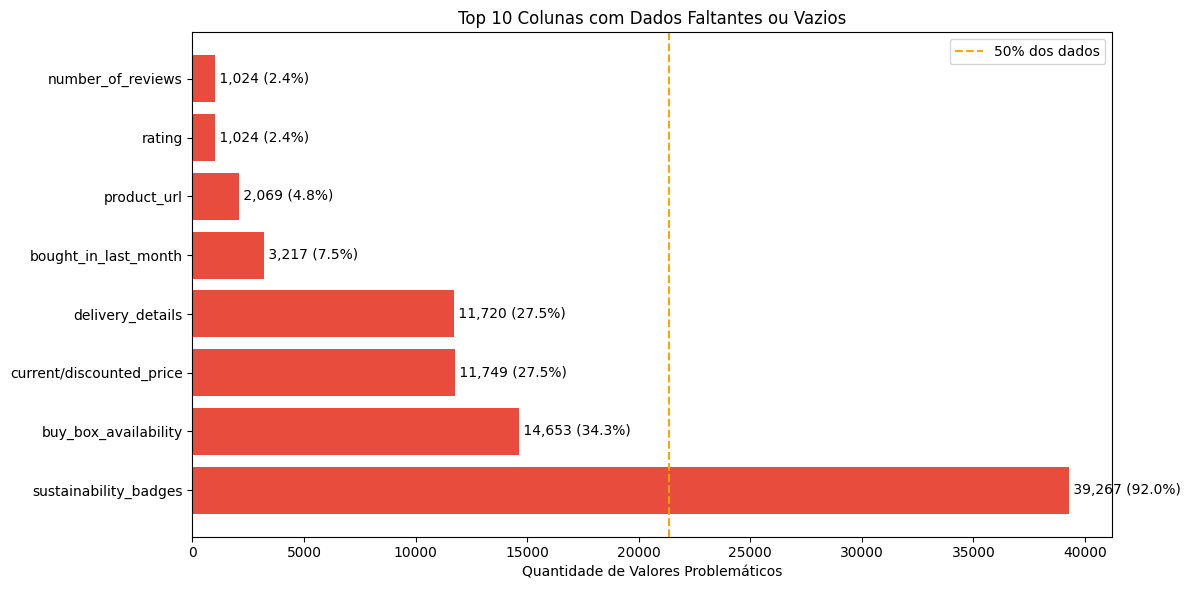

In [23]:
# Visualização de dados faltantes
fig, ax = plt.subplots(figsize=(12, 6))

colunas_problema = missing_data.head(10)['Coluna'].values
valores_problema = missing_data.head(10)['Total Problemático'].values

bars = ax.barh(colunas_problema, valores_problema, color='#e74c3c')
ax.set_xlabel('Quantidade de Valores Problemáticos')
ax.set_title('Top 10 Colunas com Dados Faltantes ou Vazios')
ax.axvline(len(df) * 0.5, color='orange', linestyle='--', label='50% dos dados')

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {valores_problema[i]:,.0f} ({valores_problema[i]/len(df)*100:.1f}%)',
            ha='left', va='center')

ax.legend()
plt.tight_layout()
plt.show()

## 2. Análise de Preços Problemáticos

In [24]:
# Identificar produtos sem preço
sem_preco_atual = df['current/discounted_price'].isnull() | (df['current/discounted_price'] == '')
sem_preco_original = df['listed_price'].isnull() | (df['listed_price'] == '') | (df['listed_price'] == 'No Discount')

print(f"⚠️  PRODUTOS SEM PREÇO")
print(f"="*50)
print(f"Sem preço atual: {sem_preco_atual.sum():,} ({sem_preco_atual.sum()/len(df)*100:.1f}%)")
print(f"Sem preço original: {sem_preco_original.sum():,} ({sem_preco_original.sum()/len(df)*100:.1f}%)")
print(f"Sem NENHUM preço: {(sem_preco_atual & sem_preco_original).sum():,}")

⚠️  PRODUTOS SEM PREÇO
Sem preço atual: 11,749 (27.5%)
Sem preço original: 30,364 (71.2%)
Sem NENHUM preço: 11,749


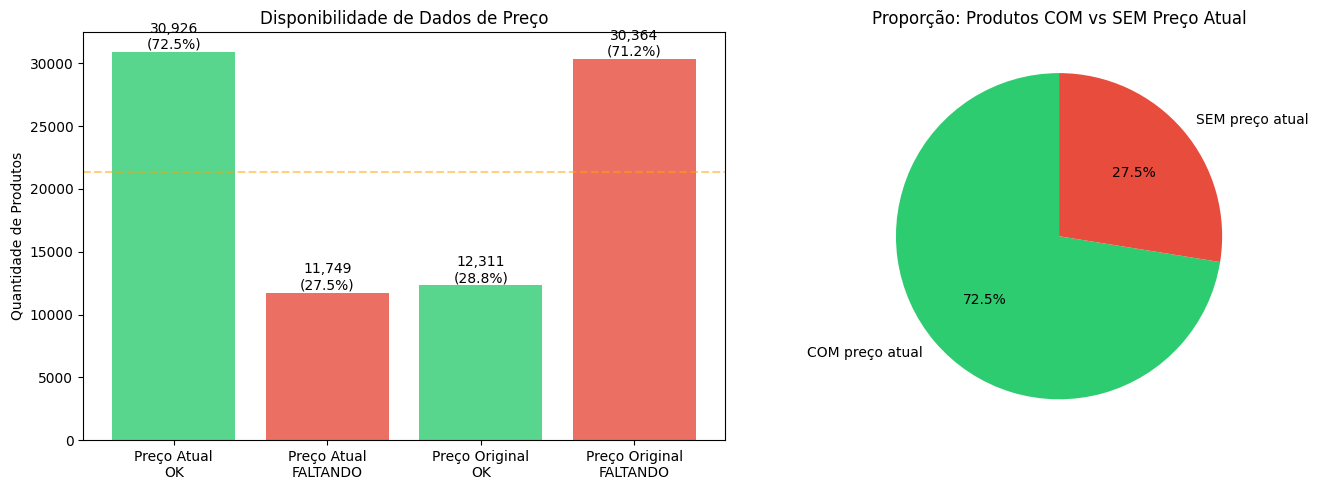

In [25]:
# Visualização de problemas de preço
categorias = ['Preço Atual\nOK', 'Preço Atual\nFALTANDO', 'Preço Original\nOK', 'Preço Original\nFALTANDO']
valores = [
    (~sem_preco_atual).sum(),
    sem_preco_atual.sum(),
    (~sem_preco_original).sum(),
    sem_preco_original.sum()
]
cores = ['#2ecc71', '#e74c3c', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
bars = ax[0].bar(categorias, valores, color=cores, alpha=0.8)
ax[0].set_ylabel('Quantidade de Produtos')
ax[0].set_title('Disponibilidade de Dados de Preço')
ax[0].axhline(len(df)/2, color='orange', linestyle='--', alpha=0.5)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2., height,
              f'{valores[i]:,.0f}\n({valores[i]/len(df)*100:.1f}%)',
              ha='center', va='bottom')

# Pizza de produtos sem preço
pizza_labels = ['COM preço atual', 'SEM preço atual']
pizza_valores = [(~sem_preco_atual).sum(), sem_preco_atual.sum()]
pizza_cores = ['#2ecc71', '#e74c3c']

ax[1].pie(pizza_valores, labels=pizza_labels, colors=pizza_cores, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Proporção: Produtos COM vs SEM Preço Atual')

plt.tight_layout()
plt.show()

## 3. Análise de Reviews Problemáticas

In [26]:
# Identificar produtos sem reviews
sem_reviews = df['number_of_reviews'].isnull() | (df['number_of_reviews'] == '')
sem_rating = df['rating'].isnull() | (df['rating'] == '')

print(f"⚠️  PRODUTOS SEM AVALIAÇÕES")
print(f"="*50)
print(f"Sem número de reviews: {sem_reviews.sum():,} ({sem_reviews.sum()/len(df)*100:.1f}%)")
print(f"Sem rating: {sem_rating.sum():,} ({sem_rating.sum()/len(df)*100:.1f}%)")
print(f"Sem reviews E sem rating: {(sem_reviews & sem_rating).sum():,}")

⚠️  PRODUTOS SEM AVALIAÇÕES
Sem número de reviews: 1,024 (2.4%)
Sem rating: 1,024 (2.4%)
Sem reviews E sem rating: 1,024


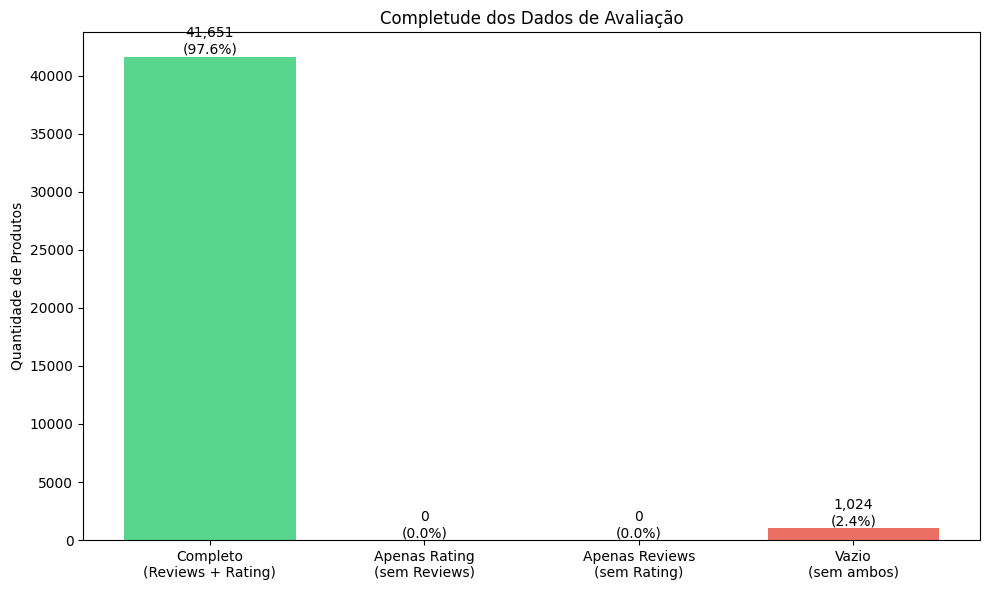

In [27]:
# Visualização de dados de reviews
fig, ax = plt.subplots(figsize=(10, 6))

categorias_rev = [
    'Completo\n(Reviews + Rating)',
    'Apenas Rating\n(sem Reviews)',
    'Apenas Reviews\n(sem Rating)',
    'Vazio\n(sem ambos)'
]

valores_rev = [
    ((~sem_reviews) & (~sem_rating)).sum(),
    (sem_reviews & (~sem_rating)).sum(),
    ((~sem_reviews) & sem_rating).sum(),
    (sem_reviews & sem_rating).sum()
]

cores_rev = ['#2ecc71', '#f39c12', '#f39c12', '#e74c3c']

bars = ax.bar(categorias_rev, valores_rev, color=cores_rev, alpha=0.8)
ax.set_ylabel('Quantidade de Produtos')
ax.set_title('Completude dos Dados de Avaliação')

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{valores_rev[i]:,.0f}\n({valores_rev[i]/len(df)*100:.1f}%)',
           ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 4. Análise de Inconsistências de Formato

In [28]:
# Analisar formatos problemáticos
import re

def tem_formato_invalido(valor, tipo='preco'):
    if pd.isna(valor) or valor == '':
        return False
    if tipo == 'preco':
        return not bool(re.search(r'\d', str(valor)))
    return False

# Preços com formato problemático
preco_atual_invalido = df['current/discounted_price'].apply(lambda x: tem_formato_invalido(x, 'preco'))
preco_original_invalido = df['listed_price'].apply(lambda x: tem_formato_invalido(x, 'preco') and x != 'No Discount')

# Reviews com formato "k" (precisam conversão)
reviews_com_k = df['number_of_reviews'].astype(str).str.contains('k|K', case=False, na=False)
reviews_com_plus = df['number_of_reviews'].astype(str).str.contains('\+', na=False)

print(f"⚠️  DADOS COM FORMATO PROBLEMÁTICO")
print(f"="*50)
print(f"Preços com formato inválido: {(preco_atual_invalido | preco_original_invalido).sum():,}")
print(f"Reviews com 'k' (6k, 1.2k): {reviews_com_k.sum():,}")
print(f"Reviews com '+' (300+): {reviews_com_plus.sum():,}")
print(f"\nTotal de registros que precisam limpeza: {((preco_atual_invalido | preco_original_invalido) | reviews_com_k | reviews_com_plus).sum():,}")

⚠️  DADOS COM FORMATO PROBLEMÁTICO
Preços com formato inválido: 0
Reviews com 'k' (6k, 1.2k): 0
Reviews com '+' (300+): 0

Total de registros que precisam limpeza: 0


In [29]:
# Exemplos de dados problemáticos
print("📋 EXEMPLOS DE DADOS PROBLEMÁTICOS:\n")

if reviews_com_k.sum() > 0:
    print("Reviews com 'k':")
    exemplos_k = df[reviews_com_k][['title', 'number_of_reviews']].head(3)
    for idx, row in exemplos_k.iterrows():
        print(f"  • {row['number_of_reviews']} reviews - {row['title'][:50]}...")

print("\nPreços 'No Discount':")
exemplos_no_discount = df[df['listed_price'] == 'No Discount'][['title', 'listed_price']].head(3)
for idx, row in exemplos_no_discount.iterrows():
    print(f"  • {row['listed_price']} - {row['title'][:50]}...")

📋 EXEMPLOS DE DADOS PROBLEMÁTICOS:


Preços 'No Discount':
  • No Discount - Apple AirPods Pro 2 Wireless Earbuds, Active Noise...
  • No Discount - Apple AirTag 4 Pack. Keep Track of and find Your K...
  • No Discount - Texas Instruments TI-84 Plus CE Color Graphing Cal...


## 5. Resumo Geral de Problemas

In [30]:
# Resumo de todos os problemas encontrados
problemas = pd.DataFrame({
    'Tipo de Problema': [
        'Produtos SEM preço atual',
        'Produtos SEM preço original',
        'Produtos SEM reviews',
        'Produtos SEM rating',
        'Reviews com formato "k"',
        'Reviews com "+"',
        'Sustainability badges vazios'
    ],
    'Quantidade': [
        sem_preco_atual.sum(),
        sem_preco_original.sum(),
        sem_reviews.sum(),
        sem_rating.sum(),
        reviews_com_k.sum(),
        reviews_com_plus.sum(),
        df['sustainability_badges'].isnull().sum()
    ],
    'Severidade': [
        'ALTA',
        'MÉDIA',
        'BAIXA',
        'BAIXA',
        'MÉDIA',
        'MÉDIA',
        'BAIXA'
    ]
})

problemas['% do Total'] = (problemas['Quantidade'] / len(df) * 100).round(2)
problemas = problemas.sort_values('Quantidade', ascending=False)

display(problemas)

,Tipo de Problema,Quantidade,Severidade,% do Total
6,Sustainability badges vazios,39267,BAIXA,92.01
1,Produtos SEM preço original,30364,MÉDIA,71.15
0,Produtos SEM preço atual,11749,ALTA,27.53
2,Produtos SEM reviews,1024,BAIXA,2.40
3,Produtos SEM rating,1024,BAIXA,2.40
4,"Reviews com formato ""k""",0,MÉDIA,0.00
5,"Reviews com ""+""",0,MÉDIA,0.00


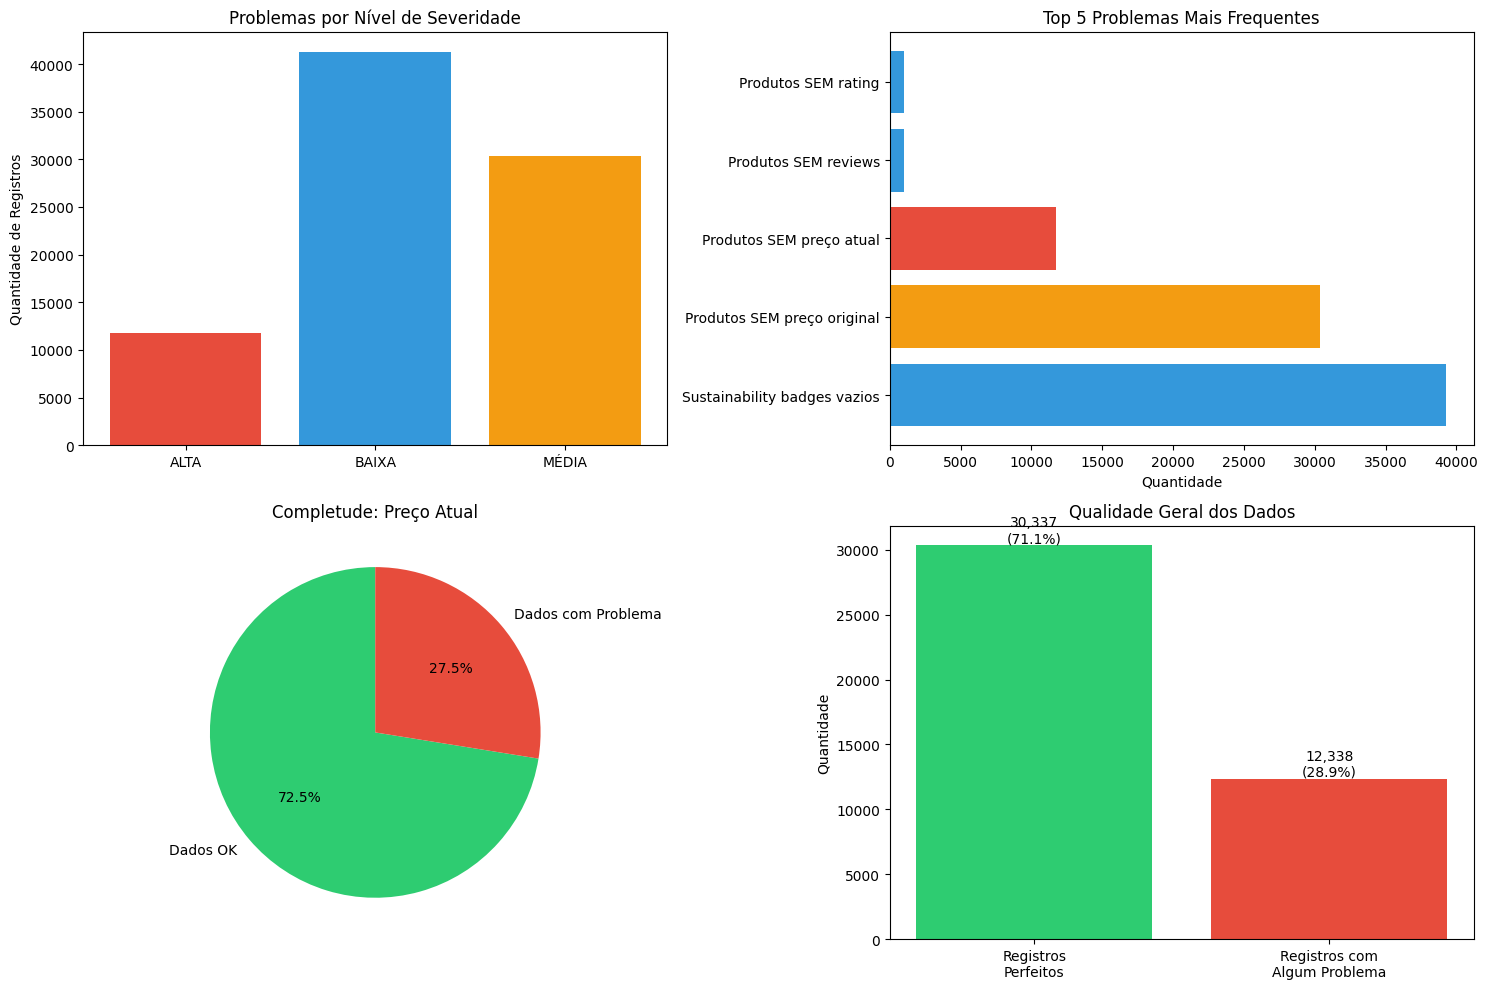

In [31]:
# Visualização final - Dashboard de problemas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Problemas por severidade
severidade_count = problemas.groupby('Severidade')['Quantidade'].sum()
cores_sev = {'ALTA': '#e74c3c', 'MÉDIA': '#f39c12', 'BAIXA': '#3498db'}
axes[0,0].bar(severidade_count.index, severidade_count.values, 
              color=[cores_sev[x] for x in severidade_count.index])
axes[0,0].set_title('Problemas por Nível de Severidade')
axes[0,0].set_ylabel('Quantidade de Registros')

# 2. Top 5 problemas
top5 = problemas.head(5)
axes[0,1].barh(top5['Tipo de Problema'], top5['Quantidade'], 
               color=[cores_sev[x] for x in top5['Severidade']])
axes[0,1].set_title('Top 5 Problemas Mais Frequentes')
axes[0,1].set_xlabel('Quantidade')

# 3. Proporção de dados limpos vs problemáticos (preço)
dados_limpos_preco = (~sem_preco_atual).sum()
dados_problematicos_preco = sem_preco_atual.sum()
axes[1,0].pie([dados_limpos_preco, dados_problematicos_preco], 
              labels=['Dados OK', 'Dados com Problema'],
              colors=['#2ecc71', '#e74c3c'],
              autopct='%1.1f%%',
              startangle=90)
axes[1,0].set_title('Completude: Preço Atual')

# 4. Estatísticas gerais
total_registros = len(df)
registros_perfeitos = ((~sem_preco_atual) & (~sem_reviews) & (~sem_rating)).sum()
registros_com_algum_problema = total_registros - registros_perfeitos

axes[1,1].bar(['Registros\nPerfeitos', 'Registros com\nAlgum Problema'],
              [registros_perfeitos, registros_com_algum_problema],
              color=['#2ecc71', '#e74c3c'])
axes[1,1].set_title('Qualidade Geral dos Dados')
axes[1,1].set_ylabel('Quantidade')

for i, v in enumerate([registros_perfeitos, registros_com_algum_problema]):
    axes[1,1].text(i, v, f'{v:,.0f}\n({v/total_registros*100:.1f}%)', 
                   ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 6. Conclusão e Necessidade de ETL

In [32]:
print("="*70)
print("📊 CONCLUSÃO: NECESSIDADE DE PROCESSO ETL")
print("="*70)

print(f"\n✅ Registros com dados completos: {registros_perfeitos:,} ({registros_perfeitos/total_registros*100:.1f}%)")
print(f"⚠️  Registros com problemas: {registros_com_algum_problema:,} ({registros_com_algum_problema/total_registros*100:.1f}%)")

print("\n🔧 AÇÕES NECESSÁRIAS NO ETL:")
print("  1. Remover produtos sem preço atual (essencial para análise)")
print("  2. Converter reviews com 'k' para números inteiros")
print("  3. Limpar formato de preços (remover $, vírgulas)")
print("  4. Tratar valores 'No Discount' no preço original")
print("  5. Preencher ou remover colunas com >90% de dados faltantes")
print("  6. Padronizar formatos de rating e reviews")

print(f"\n📈 IMPACTO ESPERADO:")
produtos_removidos = sem_preco_atual.sum()
produtos_finais = total_registros - produtos_removidos
print(f"  • Produtos a remover: {produtos_removidos:,} ({produtos_removidos/total_registros*100:.1f}%)")
print(f"  • Produtos finais: {produtos_finais:,} ({produtos_finais/total_registros*100:.1f}%)")
print(f"  • Melhoria na qualidade: significativa")

print("\n" + "="*70)

📊 CONCLUSÃO: NECESSIDADE DE PROCESSO ETL

✅ Registros com dados completos: 30,337 (71.1%)
⚠️  Registros com problemas: 12,338 (28.9%)

🔧 AÇÕES NECESSÁRIAS NO ETL:
  1. Remover produtos sem preço atual (essencial para análise)
  2. Converter reviews com 'k' para números inteiros
  3. Limpar formato de preços (remover $, vírgulas)
  4. Tratar valores 'No Discount' no preço original
  5. Preencher ou remover colunas com >90% de dados faltantes
  6. Padronizar formatos de rating e reviews

📈 IMPACTO ESPERADO:
  • Produtos a remover: 11,749 (27.5%)
  • Produtos finais: 30,926 (72.5%)
  • Melhoria na qualidade: significativa

